In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import weibull_min

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded.")

Libraries loaded.


In [5]:
FILE_PATH = './data/one_day_hamburg_multiheight_20hz.csv'

df = pd.read_csv(FILE_PATH, parse_dates=['datetime'])
df = df.set_index('datetime').sort_index()

print(f"Loaded {len(df):,} rows")
print(f"Time range: {df.index.min()}  →  {df.index.max()}")
print(f"Sampling rate: 20 Hz (every {(df.index[1]-df.index[0]).total_seconds()*1000:.0f} ms)")
print(f"Heights: 50, 110, 175, 250 m")
print(f"\nMissing values per column:")
print(df.isna().sum())
print(f"\nFirst 3 rows:")
df.head(3)

Loaded 1,728,001 rows
Time range: 2023-02-01 00:00:00  →  2023-02-02 00:00:00
Sampling rate: 20 Hz (every 50 ms)
Heights: 50, 110, 175, 250 m

Missing values per column:
wind_speed_50m_mps         82936
wind_direction_50m_deg     82936
wind_speed_110m_mps        24539
wind_direction_110m_deg    24539
wind_speed_175m_mps        29749
wind_direction_175m_deg    29749
wind_speed_250m_mps        52092
wind_direction_250m_deg    52092
dtype: int64

First 3 rows:


,wind_speed_50m_mps,wind_direction_50m_deg,wind_speed_110m_mps,wind_direction_110m_deg,wind_speed_175m_mps,wind_direction_175m_deg,wind_speed_250m_mps,wind_direction_250m_deg
datetime,,,,,,,,
2023-02-01 00:00:00.000,10.05,263.5,18.10,272.6,13.86,271.5,15.38,278.9
2023-02-01 00:00:00.050,9.67,260.8,18.18,273.6,13.95,274.2,15.44,279.4
2023-02-01 00:00:00.100,9.35,260.6,18.44,273.0,13.78,275.7,15.46,278.9


##### Likely explanation for most missing values especially in 50 meters
- They are closer to ground-level disturbance, ice, debris or sensor maintenance access.
- The 50 m might be older or noisier.

**This is very important**

To prevent accidentally inventing turbulence data, we need to make sure  that any 10-minute window we compute statistics has **atleast 50% valid samples** (the FINO/standard meteorological rule). 

Therefore, we are NOT going to interpolate or fill those NaNs. We will:

- Use np.nanmean, np.nanstd, etc., which silently ignore NaNs in calculations.



---
---

### EXPLANATION FOR TASK 7

Our sensor sits beautifully at 50 meters and it measure at 20 Hz (20 times every second). For for one second, we have 20 readings.

Now we want to zoom into just **15 minutes** of that day.
- What does the wind look like in those 15 minutes?
- What is it doing? second to second!

##### Thought process for Step 7
1. **Pick a 10 - 20 minute window**: Turbulence lives within this timescale. In a 10 minute window, the mean wind doesn't change much.
2. **Plot raw u(t) at one height**: Lets say at one height, we plot the actual wind speed as a function of time over our 15 minute window.
3. **Compute a short moving average** (window 10-30 s). We blur 30 seconds to find the slow mean flow within a 15-minute window.
4. **Subract step 2 from step 3**: What remains is the jitter.

In Task 3 we asked: "Within 3 months, how does the wind sit on top of multi-day weather and a daily rhythm?" We got the synoptic trend.

In Task 7 we ask: "Within 15 minutes, how does the wind sit on top of a 30-second-smoothed mean flow?" We get the turbulent fluctuations.

In [6]:
#(a) Choose a 15-minute window

window_start = '2023-02-01 12:00:00'
window_end   = '2023-02-01 12:15:00'

In [8]:
# we choose 110m because it has the fewest NaNs and it is modern turbine hub-height.
height = 110
col = f'wind_speed_{height}m_mps'

# Extract the 15-minute window
u = df.loc[window_start:window_end, col].dropna()
print(f"Window: {window_start} → {window_end}")
print(f"Height: {height} m, column: {col}")
print(f"Number of samples: {len(u):,}  (expected ~{15*60*20:,} for 15 min at 20 Hz)")
print(f"Mean wind: {u.mean():.2f} m/s")

Window: 2023-02-01 12:00:00 → 2023-02-01 12:15:00
Height: 110 m, column: wind_speed_110m_mps
Number of samples: 17,871  (expected ~18,000 for 15 min at 20 Hz)
Mean wind: 9.41 m/s


In [9]:
#the rolling function counts in samples, not seconds.
# therefore a 30-secondn window at 20Hz = 600 samples.
window_seconds = 30
window_samples = window_seconds * 20
u_bar = u.rolling(window=window_samples, center=True, min_periods=window_samples//2).mean()

In [10]:
#computing the Fluctuations
u_prime = u - u_bar

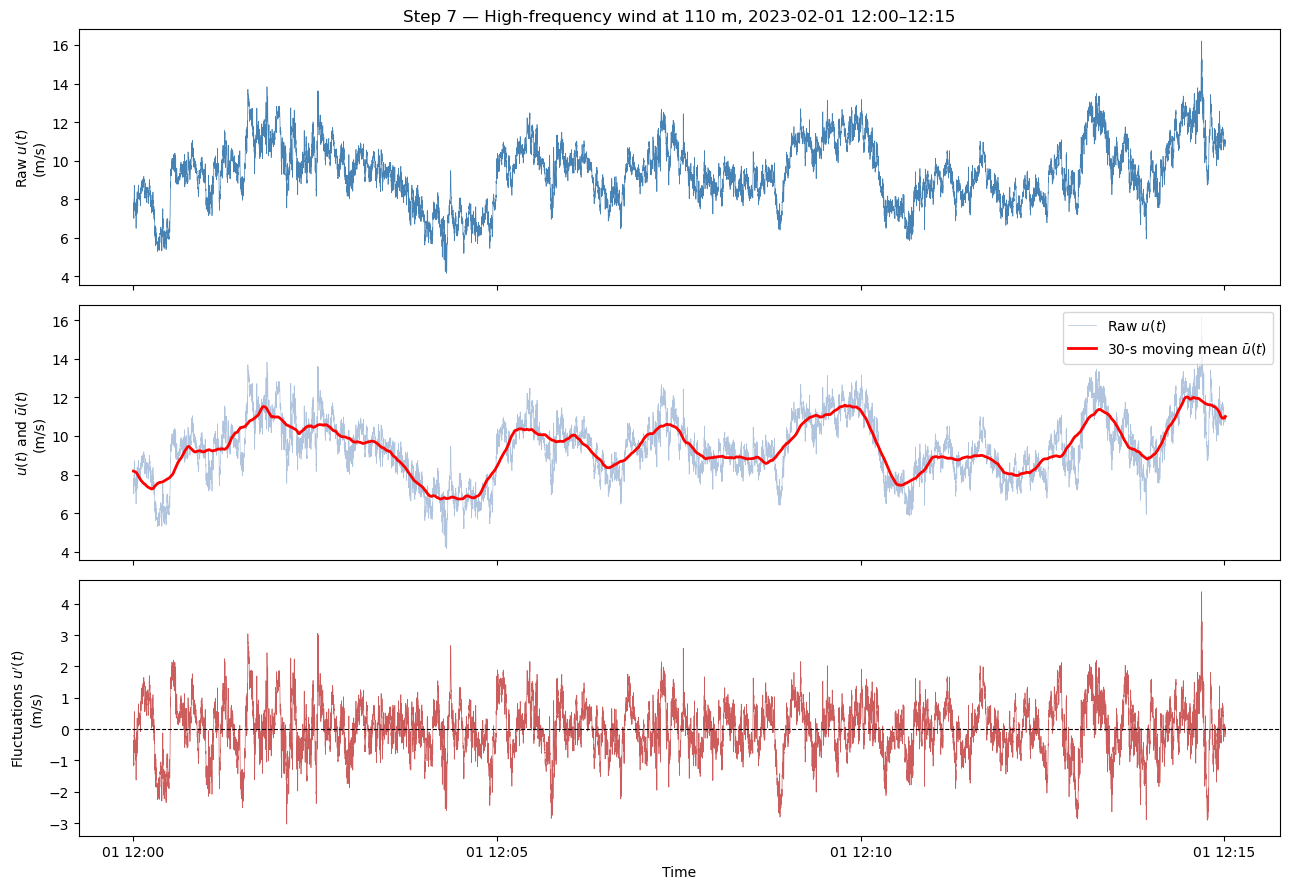


Statistics over the 15-min window:
  Mean wind speed       : 9.406 m/s
  Std dev of u(t)       : 1.587 m/s
  Std dev of fluctuations u'(t): 0.830 m/s
  Turbulence intensity TI = sigma/mean: 0.169


In [11]:
# (e) Plot — three panels: raw signal, raw + smoothed, fluctuations
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# Panel 1: raw u(t)
axes[0].plot(u.index, u.values, color='steelblue', lw=0.5)
axes[0].set_ylabel('Raw $u(t)$\n(m/s)')
axes[0].set_title(f'Step 7 — High-frequency wind at {height} m, 2023-02-01 12:00–12:15')

# Panel 2: u(t) with moving average overlaid
axes[1].plot(u.index, u.values, color='lightsteelblue', lw=0.5, label='Raw $u(t)$')
axes[1].plot(u_bar.index, u_bar.values, color='red', lw=2, label=f'30-s moving mean $\\bar{{u}}(t)$')
axes[1].set_ylabel('$u(t)$ and $\\bar{u}(t)$\n(m/s)')
axes[1].legend(loc='upper right')

# Panel 3: fluctuations u'(t)
axes[2].plot(u_prime.index, u_prime.values, color='indianred', lw=0.5)
axes[2].axhline(0, color='black', lw=0.8, ls='--')
axes[2].set_ylabel("Fluctuations $u'(t)$\n(m/s)")
axes[2].set_xlabel('Time')

plt.tight_layout()
plt.show()

# Quick summary stats
print(f"\nStatistics over the 15-min window:")
print(f"  Mean wind speed       : {u.mean():.3f} m/s")
print(f"  Std dev of u(t)       : {u.std():.3f} m/s")
print(f"  Std dev of fluctuations u'(t): {u_prime.std():.3f} m/s")
print(f"  Turbulence intensity TI = sigma/mean: {u.std()/u.mean():.3f}")

##### Message to self: (just my thoughts)
The fluctuations are not turbulence itself; they are the 1-D time-series signature of turbulent eddies passing the sensor. Turbulence is the underlying physical phenomenon; u′(t) is what we can measure of it. **TI is just the ratio of the wind's wiggle size to its average size, computed over a window (typically 10 minutes).**

In my own words, i would say the 10 minutes average, is basically a standardization for wind to be measured as such. Imagine just ignoring what actually happens within that 10 minutes mean, within these mean, there are variability at 30 s, 1 min, at 5 min etc. 


So if we had a 10min mean, let's say it would be ≈ 9.4 m/s... Look at my RED line in Panel 2 you will see that the red line within those 15 mins wandered from ~7 to ~12 m/s ( a solid a 5 m/s swing)

***a single 10-minute average compresses real mesoscale variability into the residual variance and contributes to the high apparent TI.***



#### Interpretation of Figure above

**Panel 1** - There are slow swings that take the signal from ~7 m/s up to ~13 m/s and back. There are as well fast jitters on top of those.
***there is no clean separation between turbulence and mean flow.***

**Panel 2** - The 30-second moving mean (red) wanders between roughly 7 and 12 m/s. It has its own rhythm, with peaks around minutes 2,6,9 and 14. These are the slow swells, now isolated from the fast chop. 

**Panel 3** - Fast jitter (the leftover), scattering symmetrically around zero, ranging roughly ±3 m/s with most action within ±1.5 m/s. This is what we keep after removing the slow swells. There no long calm stretches. 

### REPORT FOR TASK 7

1. *Why is the signal never steady?*
Because the atmospheric boundary layer is never laminar — shear at the surface, buoyancy effects, and inertia of advected air parcels combine to produce chaotic eddies of many sizes, continuously and inexhaustibly.


2. *What do the small-scale fluctuations physically represent?*
They are the time-domain signature of turbulent eddies passing the sensor. Each fluctuation of timescale Δt corresponds (by Taylor's frozen-turbulence hypothesis) to an eddy of streamwise size L≈uˉ⋅ΔtL ≈ \bar{u}·Δt
L≈uˉ⋅Δt.

In this data: 1-second fluctuations correspond to **~9.4 m eddies**, 100-ms fluctuations to **~0.94 m eddies**, and the largest 1-minute swells to **~560 m structures**. The u′(t) trace contains the imprint of eddies spanning roughly three orders of magnitude in size.


3. *How do they relate to turbine performance and fatigue?*
Each fluctuation produces a momentary change in the angle of attack and lift on a turbine blade. A 17% TI means the blade is subjected to load fluctuations of order ±17% of its mean operating load, occurring many thousands of times per minute. Over years of operation, this drives metal fatigue in blades and tower, limiting turbine lifetime. The IEC turbine-design standards explicitly require turbines to be rated for sustained TI in this range.

---
---

### EXPLANATION FOR TASK 8

**Friendly Recap:** At the other end of this two beautiful straight lines, we saw how wiggles are in a 15 mins average viewing at 30 seconds moving mean. Even more interesting, we saw fast jitter (panel 3), scattering symmetrically around zero, ranging roughly ±3 m/s with most action within ±1.5 m/s. 

*This feels like PEELING AN ONION* :)

---

We are looking how turbulence changes wiht height.

As you go up:

- Shear weakens (the wind speed gradient flattens out)
- Buoyancy weakens (you're farther from the heated surface)
- The mean wind speed grows (numerator of TI doesn't help)
- The fluctuations decay (numerator of TI shrinks)

#### Thought process for Step 8
1. 